# Cross-Domain Self-Supervised Vision Transformer for Robust Deepfake Detection

---

## Overview & Exploratory Data Analysis (EDA)

This notebook covers:

- Project Overview
- Problem Definition
- Dataset Description
- Data Loading
- Exploratory Data Analysis
- Domain Shift Insights

This phase focuses on **data understanding before model building**.

## 1. Overview

Deepfake detection systems often fail due to:

- Overfitting to specific datasets
- Poor cross-domain generalization
- Sensitivity to noise and compression
- Lack of interpretability

This project proposes:

- Self-Supervised Contrastive Learning
- Vision Transformer Backbone
- Cross-Domain Evaluation
- Robustness Testing
- Streamlit Deployment

The objective is to build a robust, generalizable, and explainable deepfake detection system.

## 2. Problem Definition

Given an input facial image, classify it as:

- Real (0)
- Fake (1)

Constraints:

- Must generalize to unseen data
- Must remain stable under perturbations
- Must provide interpretable predictions

Evaluation Metrics:

- Accuracy
- F1-score
- ROC-AUC

## 3. Dataset Description

Dataset Used:
**140K Real and Fake Faces (Kaggle)**

Structure:

data/
    train/
        real/
        fake/
    valid/
        real/
        fake/

Dataset Characteristics:

- Balanced real and fake samples
- Pre-cropped face images
- Suitable for binary classification
- Variation in lighting and resolution

## Core Libraries

In [2]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

## Visualization

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

## Set plot style

In [4]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (6,4)

## Dataset Paths

In [11]:
DATA_DIR = r"D:\Downloads Alt\archive\real_vs_fake\real-vs-fake"

import glob
import os

train_real = glob.glob(os.path.join(DATA_DIR, "train/real/*.jpg"))
train_fake = glob.glob(os.path.join(DATA_DIR, "train/fake/*.jpg"))

valid_real = glob.glob(os.path.join(DATA_DIR, "valid/real/*.jpg"))
valid_fake = glob.glob(os.path.join(DATA_DIR, "valid/fake/*.jpg"))

print("Train Real:", len(train_real))
print("Train Fake:", len(train_fake))

Train Real: 50000
Train Fake: 50000


## 4. Class Distribution

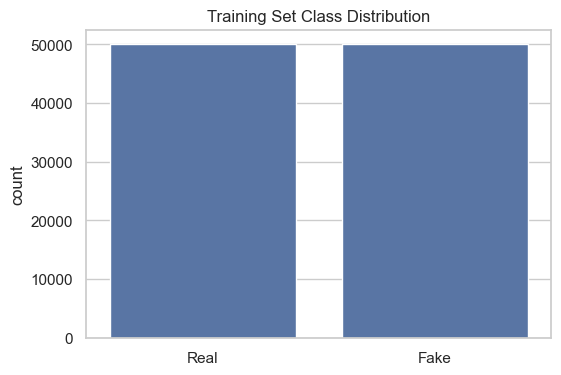

In [12]:
labels = ["Real"]*len(train_real) + ["Fake"]*len(train_fake)

sns.countplot(x=labels)
plt.title("Training Set Class Distribution")
plt.show()

### Observation

- Dataset is approximately balanced.
- Accuracy alone is insufficient.
- F1-score and ROC-AUC will be emphasized.

## 5. Sample Image Visualization

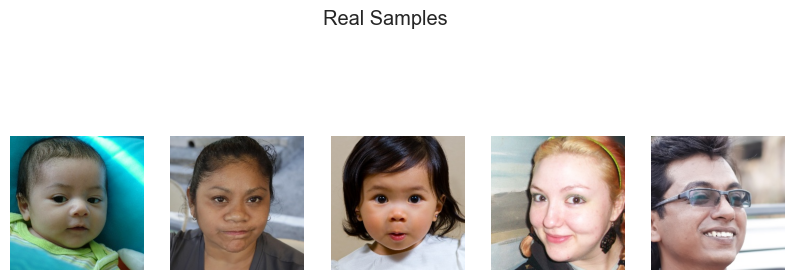

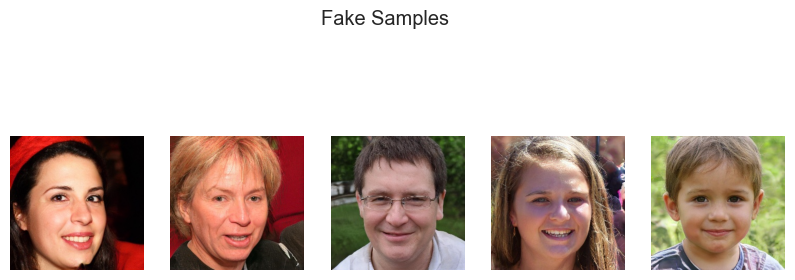

In [13]:
def show_samples(image_list, title):
    plt.figure(figsize=(10,4))
    for i in range(5):
        img = cv2.imread(image_list[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_samples(train_real, "Real Samples")
show_samples(train_fake, "Fake Samples")

## 6. Image Resolution Analysis

In [14]:
sizes = []

for path in train_real[:500]:
    img = cv2.imread(path)
    h, w, _ = img.shape
    sizes.append((h, w))

sizes = np.array(sizes)

print("Average Height:", sizes[:,0].mean())
print("Average Width:", sizes[:,1].mean())
print("Min Height:", sizes[:,0].min())
print("Max Height:", sizes[:,0].max())

Average Height: 256.0
Average Width: 256.0
Min Height: 256
Max Height: 256


### Insight

- Resolution varies across samples.
- Images will be resized to 224x224 for ViT compatibility.

## 7. Pixel Intensity Distribution

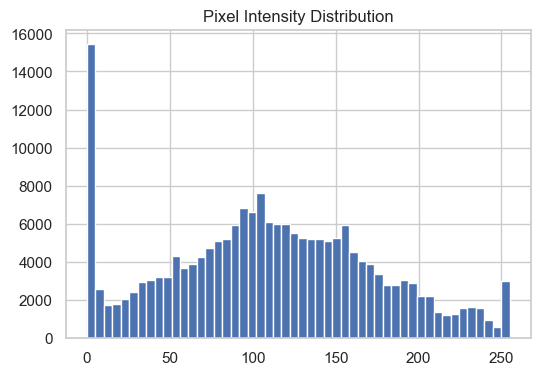

In [15]:
sample_img = cv2.imread(train_real[0])
plt.hist(sample_img.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

### Insight

- Pixel intensity distribution varies.
- Normalization is required during preprocessing.

## 8. Domain Shift Analysis

Potential domain shift sources:

- Lighting variation
- Resolution differences
- Compression artifacts
- Background inconsistencies

Implication:

Supervised learning alone may overfit.

Therefore, self-supervised contrastive learning is used to:
- Learn invariant representations
- Improve cross-domain robustness

## 9. EDA Conclusion

Key Findings:

- Dataset is balanced.
- Resolution varies significantly.
- Pixel intensity distribution requires normalization.
- Visual differences exist between samples.

Next Step:

Proceed to Self-Supervised Pretraining to learn robust representations.